In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset (using '../' to go up one folder level from /notebooks)
df = pd.read_csv('../data/Crop_recommendation.csv', on_bad_lines='skip')

# Display the first 5 rows to ensure it loaded correctly
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [4]:
print("--- DATASET INFO ---")
df.info()

print("\n--- MISSING VALUES ---")
print(df.isnull().sum())

print("\n--- STATISTICAL SUMMARY ---")
display(df.describe())

--- DATASET INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            4898 non-null   int64  
 1   P            4898 non-null   int64  
 2   K            4898 non-null   int64  
 3   temperature  4898 non-null   float64
 4   humidity     4898 non-null   float64
 5   ph           4898 non-null   float64
 6   rainfall     4898 non-null   float64
 7   label        4898 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 306.2+ KB

--- MISSING VALUES ---
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

--- STATISTICAL SUMMARY ---


,N,P,K,temperature,humidity,ph,rainfall
count,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000
mean,56.372601,47.826868,50.641486,26.077335,75.614290,6.264820,172.716952
std,31.396406,24.513544,37.663369,4.280689,16.780327,0.678730,86.389782
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,30.000000,33.000000,30.000000,23.552205,68.519750,5.818515,96.642630
50%,54.000000,46.000000,42.000000,26.130000,80.720000,6.226712,180.195000
75%,82.000000,58.000000,55.000000,28.780000,86.492752,6.650000,238.765000
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,448.980000


plt.figure(figsize=(15, 6))
sns.countplot(data=df, x='label', palette='viridis')
plt.title('Distribution of Crops in Dataset', fontsize=16)
plt.xticks(rotation=90)
plt.ylabel('Number of Rows')
plt.show()

# Create a grid of histograms for all numeric features
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

plt.figure(figsize=(15, 10))

for i, feature in enumerate(features, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[feature], kde=True, bins=30)  # 👈 updated
    plt.title(f'Distribution of {feature}')

plt.tight_layout()
plt.show()

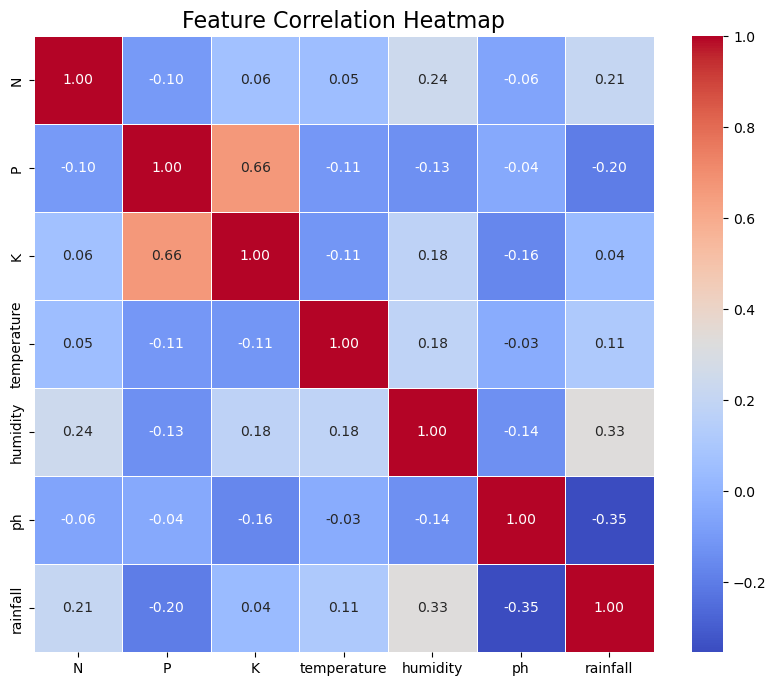

In [7]:
plt.figure(figsize=(10, 8))

# Calculate correlation (numeric_only=True prevents errors from the 'label' text column)
correlation_matrix = df.corr(numeric_only=True)

# Plot the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap", fontsize=16)
plt.show()